<a href="https://colab.research.google.com/github/azrapatvi/Ml_practice/blob/main/19_loan_class_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ninzaami/loan-predication")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-predication' dataset.
Path to dataset files: /kaggle/input/loan-predication


In [ ]:
import os

df=pd.read_csv(os.path.join(path,'train_u6lujuX_CVtuZ9i (1).csv'))

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [ ]:
cat_cols.remove('Loan_ID')

In [ ]:
for i in cat_cols:
  print(i)
  print(df[i].unique())
  print("*"*20)
  print()

Gender
['Male' 'Female' nan]
********************

Married
['No' 'Yes' nan]
********************

Dependents
['0' '1' '2' '3+' nan]
********************

Education
['Graduate' 'Not Graduate']
********************

Self_Employed
['No' 'Yes' nan]
********************

Property_Area
['Urban' 'Rural' 'Semiurban']
********************

Loan_Status
['Y' 'N']
********************



In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df['Credit_History'].median()

1.0

In [ ]:
df.columns=df.columns.str.lower().str.strip()

In [ ]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['married'] = df['married'].fillna(df['married'].mode()[0])
df['dependents'] = df['dependents'].fillna(df['dependents'].mode()[0])
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

In [ ]:
df['loanamount'] = df['loanamount'].fillna(df['loanamount'].median())

df['loan_amount_term'] = df['loan_amount_term'].fillna(
    df['loan_amount_term'].mode()[0]
)

df['credit_history'] = df['credit_history'].fillna(
    df['credit_history'].mode()[0]
)

In [ ]:
df['loanamount'] = df['loanamount'].fillna(df['loanamount'].median())

df['loan_amount_term'] = df['loan_amount_term'].fillna(
    df['loan_amount_term'].mode()[0]
)

df['credit_history'] = df['credit_history'].fillna(
    df['credit_history'].mode()[0]
)

In [ ]:
df.isnull().sum()

,0
loan_id,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicantincome,0
coapplicantincome,0
loanamount,0
loan_amount_term,0


loan_status
Y    422
N    192
Name: count, dtype: int64



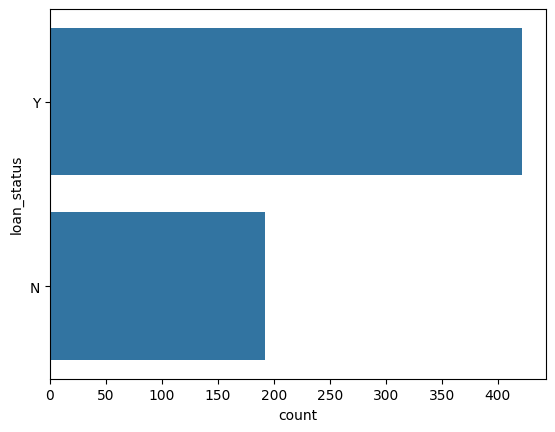

In [ ]:
print(df['loan_status'].value_counts())
print()

sns.countplot(df['loan_status'])
plt.show()

In [ ]:
df.head(2)

,loan_id,gender,married,dependents,education,self_employed,applicantincome,coapplicantincome,loanamount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [ ]:
cat_cols=[i for i in df.columns if df[i].dtypes=='O']
cat_cols

['loan_id',
 'gender',
 'married',
 'dependents',
 'education',
 'self_employed',
 'property_area',
 'loan_status']

In [ ]:
cat_cols.remove('loan_id')

In [ ]:
for i in cat_cols:
  print(i)
  print(df[i].unique())
  print("*"*20)
  print()

gender
['Male' 'Female']
********************

married
['No' 'Yes']
********************

dependents
['0' '1' '2' '3+']
********************

education
['Graduate' 'Not Graduate']
********************

self_employed
['No' 'Yes']
********************

property_area
['Urban' 'Rural' 'Semiurban']
********************

loan_status
['Y' 'N']
********************



In [ ]:
# encode the categorical columns into numerics ones

df['gender']=df['gender'].map({
    'Female':1,
    'Male':0
})

df['married']=df['married'].map({
    'Yes':1,
    'No':0
})

df['education']=df['education'].map({
    'Graduate':1,
    'Not Graduate':0
})

df['self_employed'] = df['self_employed'].map({
    'Yes': 1,
    'No': 0
})



In [ ]:
df["loan_status"] = df["loan_status"].map({
    "N": 1, #minority class
    "Y": 0 #majority class
})

In [ ]:
df['dependents'] = df['dependents'].replace('3+', '3')

In [ ]:
df['dependents'].unique()

array(['0', '1', '2', '3'], dtype=object)

In [ ]:
num_cols=[i for i in df.columns if df[i].dtypes!='O']
num_cols

['gender',
 'married',
 'education',
 'self_employed',
 'applicantincome',
 'coapplicantincome',
 'loanamount',
 'loan_amount_term',
 'credit_history',
 'loan_status']

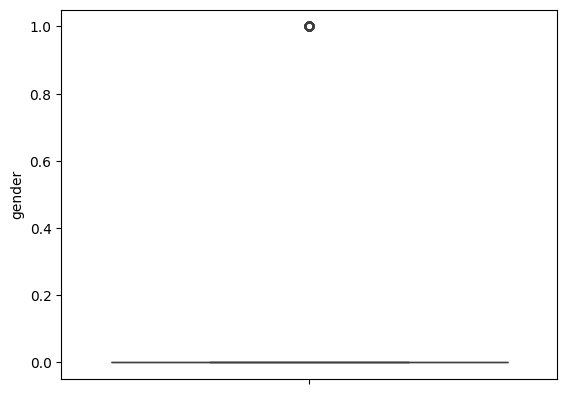

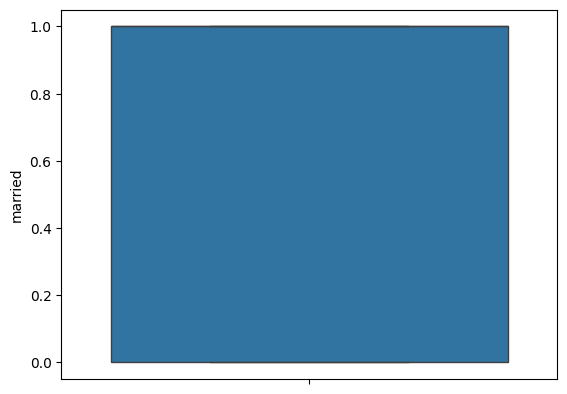

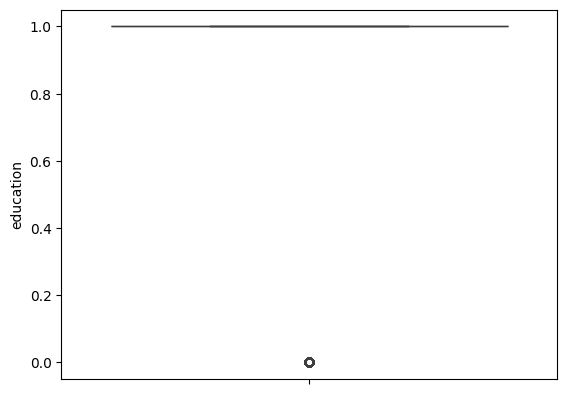

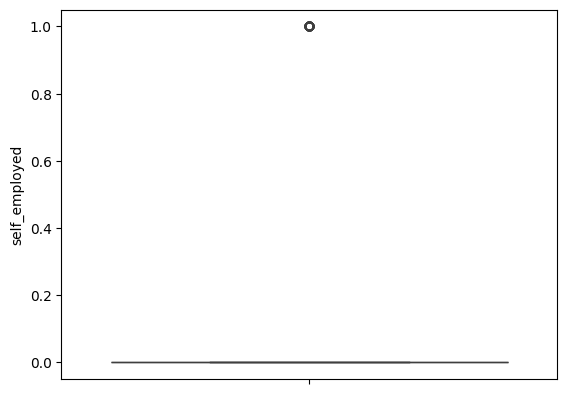

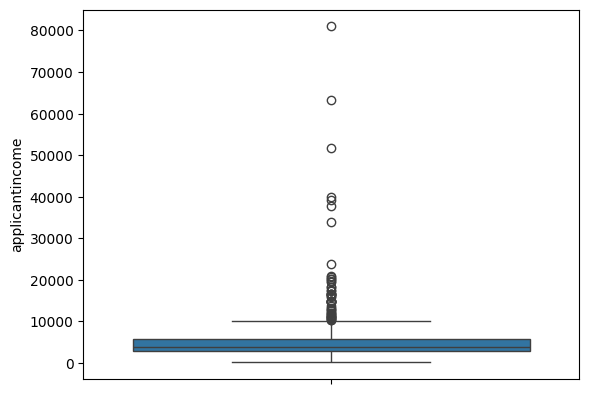

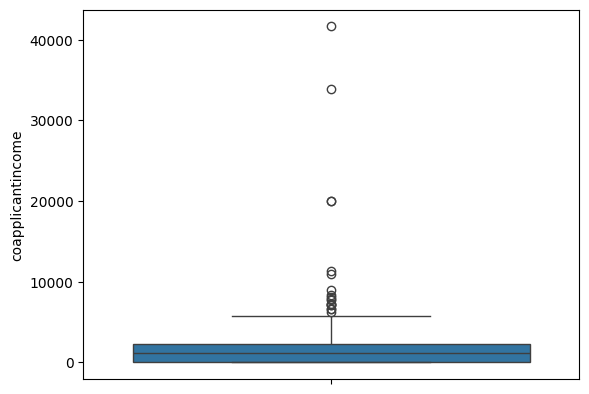

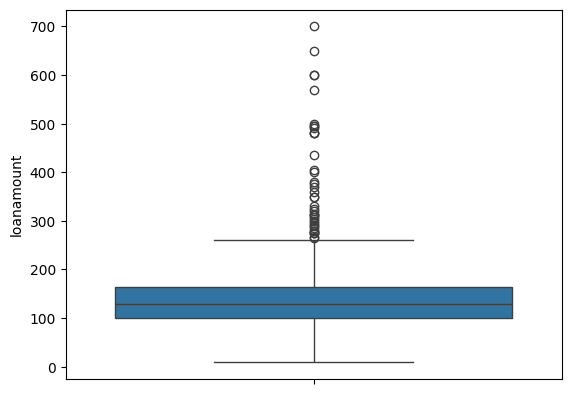

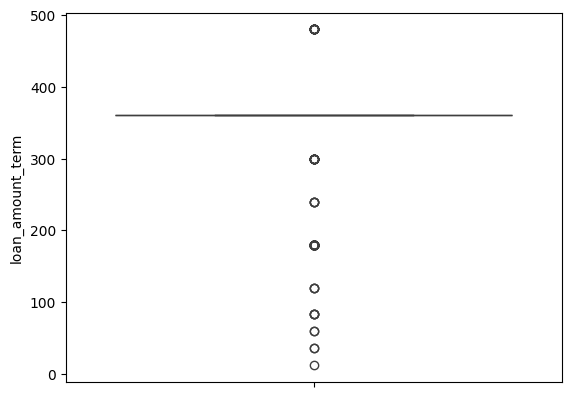

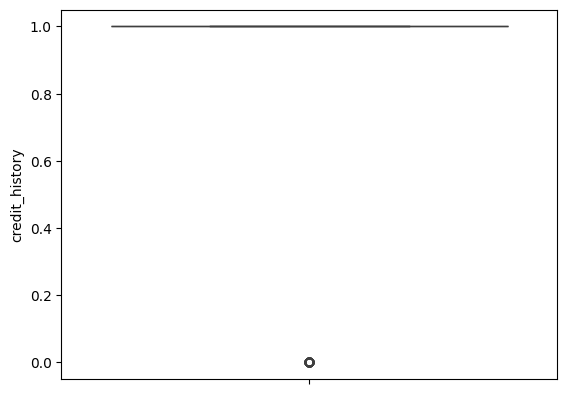

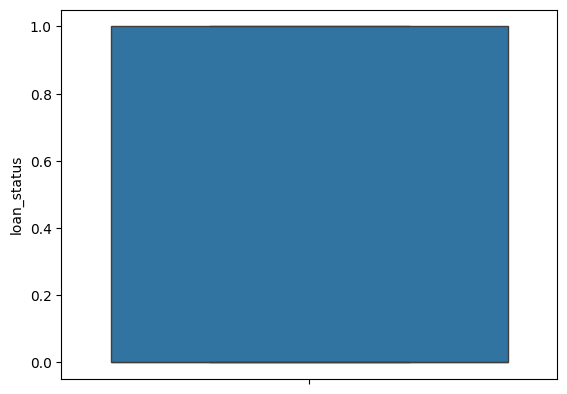

In [ ]:
for i in num_cols:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
X=df.drop('loan_status',axis=1)
y=df['loan_status']

In [ ]:
#train_test_split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder,FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


#skew_pipeline
skew_pipeline=Pipeline([
    ("simple_imputer",FunctionTransformer(np.log1p)),
    ("scaler",StandardScaler())
])
skewed_cols=['applicantincome','coapplicantincome','loanamount',]


#normal_numeric_cols
normal_pipeline=Pipeline([
    ("scaler",StandardScaler())
])
normal_num_cols=['loan_amount_term']


#ohe for prperty type
ohe_pipeline=Pipeline([
    ("ohe",OneHotEncoder(handle_unknown='ignore',drop='first'))
])
ohe_cols=['property_area']


df['dependents'] = df['dependents'].astype(int)

passthrough_cols = ['gender','married','education','self_employed','dependents','credit_history']

preprocessor = ColumnTransformer([
    ("skewed_cols", skew_pipeline, skewed_cols),
    ("normal_cols", normal_pipeline, normal_num_cols),
    ("ohe", ohe_pipeline, ohe_cols),
    ("passthrough_cols", "passthrough", passthrough_cols)
])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('skewed_cols',
                                 Pipeline(steps=[('simple_imputer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['applicantincome', 'coapplicantincome',
                                  'loanamount']),
                                ('normal_cols',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['loan_amount_term']),
                                ('ohe',
                                 Pipeline(steps=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['property_area']),
                                ('passthrough_cols', 'passthrough',
                                 ['gender', 'married', 'education',
                                  'self_employed', 'dependents',
                                  'credit_history'])])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

#Y = 422  |0
# N = 192 |1

#after encoding N->1 (positive claasss)
# Y->0 (negative class)

# xgb for imbalanced we have to use scale pos weight
# scale_pso_weight=negative class/posititve class

models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced"),
    "KNN": KNeighborsClassifier(weights="distance"),
    "SVM": SVC(class_weight="balanced"),
    "XGBoost":XGBClassifier(
        scale_pos_weight=422/192,
        random_state=42
    )
}

for name,model in models.items():
  print()
  print(name)

  pipe=Pipeline([
      ("preprocessor",preprocessor),
      ("model",model)
  ])

  pipe.fit(X_train,y_train)

  y_pred = pipe.predict(X_test)

  # Evaluation metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

  print("Accuracy :", accuracy)
  print("Precision:", precision)
  print("Recall   :", recall)
  print("F1 Score :", f1)

  print("\nConfusion Matrix:")
  print(confusion_matrix(y_test, y_pred))

  print("\nClassification Report:")
  print(classification_report(y_test, y_pred))
  print("***"*20)


Logistic Regression
Accuracy : 0.7398373983739838
Precision: 0.5882352941176471
Recall   : 0.5263157894736842
F1 Score : 0.5555555555555556

Confusion Matrix:
[[71 14]
 [18 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        85
           1       0.59      0.53      0.56        38

    accuracy                           0.74       123
   macro avg       0.69      0.68      0.69       123
weighted avg       0.73      0.74      0.74       123

************************************************************

Decision Tree
Accuracy : 0.6829268292682927
Precision: 0.4888888888888889
Recall   : 0.5789473684210527
F1 Score : 0.5301204819277109

Confusion Matrix:
[[62 23]
 [16 22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        85
           1       0.49      0.58      0.53        38

    accuracy                           0.68     

In [ ]:
from sklearn.model_selection import GridSearchCV

selected_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced"),
    "SVM": SVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=422/192, random_state=42)
}

params = {
    "Logistic Regression": {
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "penalty": ["l1", "l2"],
        "solver": ["liblinear"],
        "max_iter": [500]
    },
    "SVM": {
        "C": [0.1, 1, 10, 100],
        "kernel": ["linear", "rbf", "poly"],
        "gamma": ["scale", "auto"]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200, 300],
        "max_depth": [3, 5, 7, 9],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0]
    }
}

best_pipes = {}

for name, model in selected_models.items():
    print()
    print(name)

    grid = GridSearchCV(estimator=model, param_grid=params[name], cv=5, scoring='f1', n_jobs=-1)

    pipe2 = Pipeline([
        ("preprocessor", preprocessor),
        ("model", grid)
    ])

    pipe2.fit(X_train, y_train)
    best_pipes[name] = pipe2

    y_pred = pipe2.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print()

    print("Best Parameters:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)

    print("****" * 20)


Logistic Regression
Accuracy : 0.7398373983739838
Precision: 0.59375
Recall   : 0.5
F1 Score : 0.5428571428571428

Best Parameters: {'C': 100, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1: 0.6156640872471555
********************************************************************************

SVM
Accuracy : 0.7073170731707317
Precision: 0.5227272727272727
Recall   : 0.6052631578947368
F1 Score : 0.5609756097560976

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV F1: 0.6119411655358304
********************************************************************************

Random Forest
Accuracy : 0.7642276422764228
Precision: 0.6666666666666666
Recall   : 0.47368421052631576
F1 Score : 0.5538461538461539

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.5795333736031412
********************************************************************************

XGBoost
Acc

In [ ]:
new_model = XGBClassifier(
    colsample_bytree=0.85,
    learning_rate=0.2,
    max_depth=5,
    n_estimators=200,
    subsample=1.0,
    scale_pos_weight=422/192,
    random_state=42
)

new_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", new_model)
])

In [ ]:
new_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skewed_cols',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['applicantincome',
                                                   'coapplicantincome',
                                                   'loanamount']),
                                                 ('normal_cols',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amount_term']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
new_pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skewed_cols',
                                                  Pipeline(steps=[('simple_imputer',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['applicantincome',
                                                   'coapplicantincome',
                                                   'loanamount']),
                                                 ('normal_cols',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amount_term']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.2,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred = new_pipe.predict(X_test)

In [ ]:

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Y", "N"]
))

Accuracy : 0.7235772357723578
Precision: 0.55
Recall   : 0.5789473684210527
F1 Score : 0.5641025641025641

Confusion Matrix:
[[67 18]
 [16 22]]

Classification Report:
              precision    recall  f1-score   support

           Y       0.81      0.79      0.80        85
           N       0.55      0.58      0.56        38

    accuracy                           0.72       123
   macro avg       0.68      0.68      0.68       123
weighted avg       0.73      0.72      0.73       123

